# 01 · Bring your own model

Any deterministic model works with GPU if it implements the `BaseForwardModel` contract:

- `n_parameters(n_features) -> int`
- `forward(X, params) -> [n_samples, n_particles]` (vectorised over particles)

The optimiser owns the parameters; the model just evaluates them.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from foresight_gpu import GPURegressor
from foresight_gpu.models import BaseForwardModel
from foresight_gpu.utils import plot_timeseries, plot_qq

### A linear forward model in a dozen lines

The model owns its units: `forward` must return values directly comparable with `y`. Here
`X` lies in [-1, 1] and `y` is of order 1, well inside the default parameter bounds (±30),
so no scaling is needed. `03_extra_diagnostics` shows the `Pipeline` route when it is.

In [2]:
class LinearModel(BaseForwardModel):
    def n_parameters(self, n_features):
        return n_features + 1              # weights + bias

    def forward(self, X, params):
        params = np.atleast_2d(params)     # [n_particles, n_features + 1]
        w, b = params[:, :-1], params[:, -1]
        return np.einsum('nf,pf->np', X, w) + b[None, :]  # [n_samples, n_particles]

### Drop it into `GPURegressor`

R2 = 0.874
bands shape (400, 5)


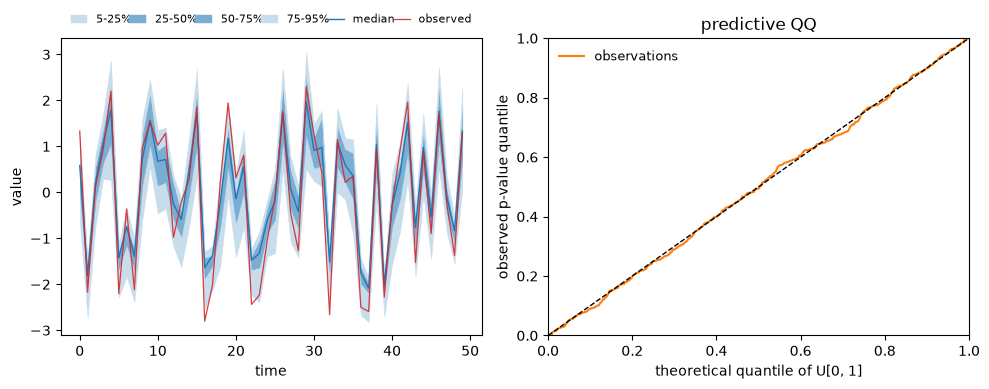

In [ ]:
rng = np.random.default_rng(0)
X = rng.uniform(-1, 1, size=(400, 3))
y = 2 * X[:, 0] - X[:, 1] + 0.3 * rng.standard_normal(400)
plot_window = 50

gpu = GPURegressor(model=LinearModel(), metric='nse', population=300,
                   n_iter=80, random_state=0).fit(X, y)

quantiles = [0.05, 0.25, 0.5, 0.75, 0.95]
bands = gpu.predict_quantiles(X, quantiles=quantiles)
print('R2 =', round(gpu.score(X, y), 3))
print('bands shape', bands.shape)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 6))
plot_timeseries(bands[:plot_window, :], quantiles, observed=y[:plot_window], ax=ax0, color='C0')
plot_qq(gpu.predictive_pvalues(X, y), ax=ax1)
ax1.set_title('predictive QQ')
fig.tight_layout()

That is all it takes. The built-in `MLPModel` and the hydrological `GR4JModel` follow the same
contract — see `foresight_gpu/models/` and the next notebook.

**Notebooks:** `00_quickstart` · `01_custom_model` · `02_gr4j` · `03_extra_diagnostics` ·
`04_uncertainty_experiments`